In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import ast
import re

In [2]:
df = pd.read_csv("df_EDA_narrow.csv")

In [3]:
df_exploded = pd.read_csv("EDA_explod_narrow.csv")

In [4]:
df_skill_focus = pd.read_csv("df_skill_focus.csv")

In [5]:
# core_skills = [

#     # programming
#     'python',
#     'sql',
#     'r',

#     # spreadsheets / BI
#     'excel',
#     'power bi',
#     'tableau',

#     # data libraries
#     'pandas',
#     'numpy',

#     # machine learning
#     'machine learning',
#     'deep learning',
#     'nlp',
#     'natural language processing',

#     # cloud / big data
#     'aws',
#     'spark',
#     'hadoop',

#     # analytics concepts
#     'data analysis',
#     'data analytics',
#     'data visualization',
#     'data modeling',
#     'statistics',

#     # databases
#     'sql server',
#     'postgresql',
#     'mysql',

#     # engineering / workflow
#     'etl',
#     'data warehousing',

# ]

In [6]:
# df_skill_focus = df_exploded[
#     df_exploded['skills'].isin(core_skills)
# ]

In [7]:
# job_cols = [
#     'company',
#     'job_tittle',
#     'location',
#     'salary_mid'
# ]

# df_skill_focus = (
#     df_skill_focus
#     .drop_duplicates(subset=job_cols + ['skills'])
# )

In [8]:
# skill_counts = (
#     df_skill_focus['skills']
#     .value_counts()
# )

# valid_skills = skill_counts[
#     skill_counts >= 5
# ].index

# df_skill_focus = df_skill_focus[
#     df_skill_focus['skills'].isin(valid_skills)
# ]

In [9]:
top_skills = (
    df_skill_focus['skills']
    .value_counts()
    .reset_index()
)

top_skills.columns = ['skill', 'job_count']

In [10]:
top_skills

,skill,job_count
0,python,664
1,sql,644
2,data analysis,483
3,machine learning,459
4,power bi,407
5,tableau,231
6,nlp,169
7,excel,159
8,data modeling,157
9,aws,145


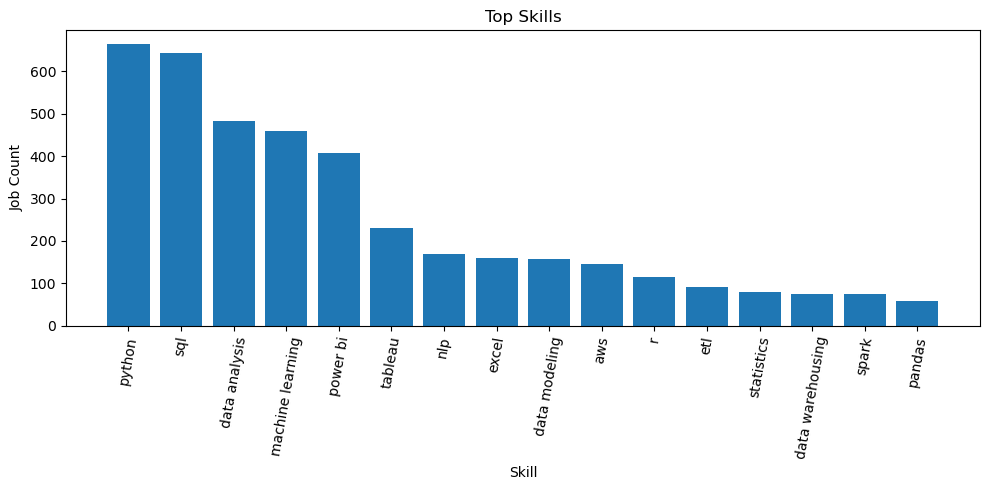

In [11]:
plt.figure(figsize=(10,5))

plt.bar(top_skills['skill'], top_skills['job_count'])

plt.xticks(rotation=80)
plt.xlabel('Skill')
plt.ylabel('Job Count')
plt.title('Top Skills')
plt.tight_layout()

In [12]:
total_jobs = df.shape[0]

top_skills['demand_pct'] = (
    top_skills['job_count'] / total_jobs * 100
).round(2)

In [13]:
top_skills

,skill,job_count,demand_pct
0,python,664,36.73
1,sql,644,35.62
2,data analysis,483,26.71
3,machine learning,459,25.39
4,power bi,407,22.51
5,tableau,231,12.78
6,nlp,169,9.35
7,excel,159,8.79
8,data modeling,157,8.68
9,aws,145,8.02


<BarContainer object of 16 artists>

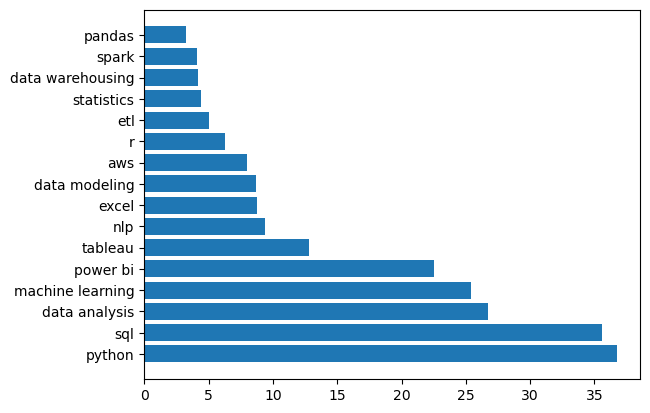

In [14]:
plt.barh(top_skills['skill'], top_skills['demand_pct'])

In [15]:
skill_salary = (
    df_skill_focus
    .groupby('skills')
    .agg(
        avg_salary=('salary_mid', 'mean'),
        median_salary=('salary_mid', 'median'),
        job_count=('skills', 'count')
    )
    .reset_index()
)

In [16]:
skill_salary

,skills,avg_salary,median_salary,job_count
0,aws,15.537931,12.5,145
1,data analysis,10.417531,8.0,483
2,data modeling,13.676282,8.0,157
3,data warehousing,10.666667,8.0,75
4,etl,11.754396,8.0,91
5,excel,7.307753,4.5,159
6,machine learning,15.358388,12.5,459
7,nlp,16.923817,12.5,169
8,pandas,13.650862,12.5,58
9,power bi,11.326663,8.0,407


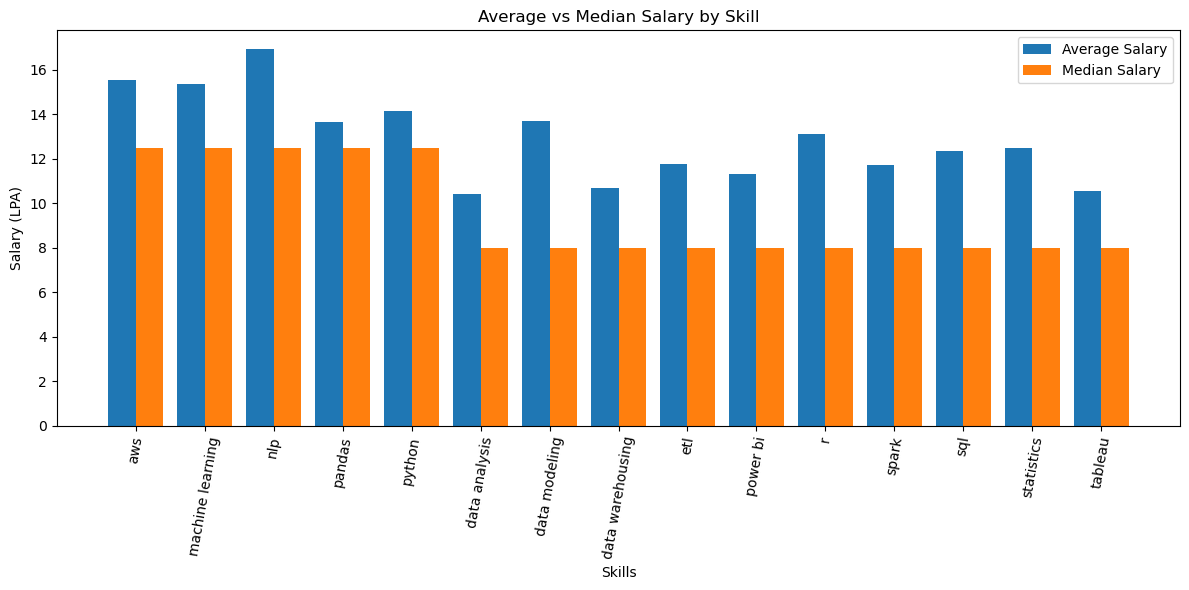

In [17]:
top_salary_skills = skill_salary.sort_values(
    'median_salary',
    ascending=False
).head(15)

plt.figure(figsize=(12,6))

x = range(len(top_salary_skills))

# avg salary bars
plt.bar(
    x,
    top_salary_skills['avg_salary'],
    width=0.4,
    label='Average Salary'
)

# median salary bars
plt.bar(
    [i + 0.4 for i in x],
    top_salary_skills['median_salary'],
    width=0.4,
    label='Median Salary'
)

plt.xticks(
    [i + 0.2 for i in x],
    top_salary_skills['skills'],
    rotation=80
)

plt.xlabel('Skills')
plt.ylabel('Salary (LPA)')
plt.title('Average vs Median Salary by Skill')

plt.legend()

plt.tight_layout()

plt.show()

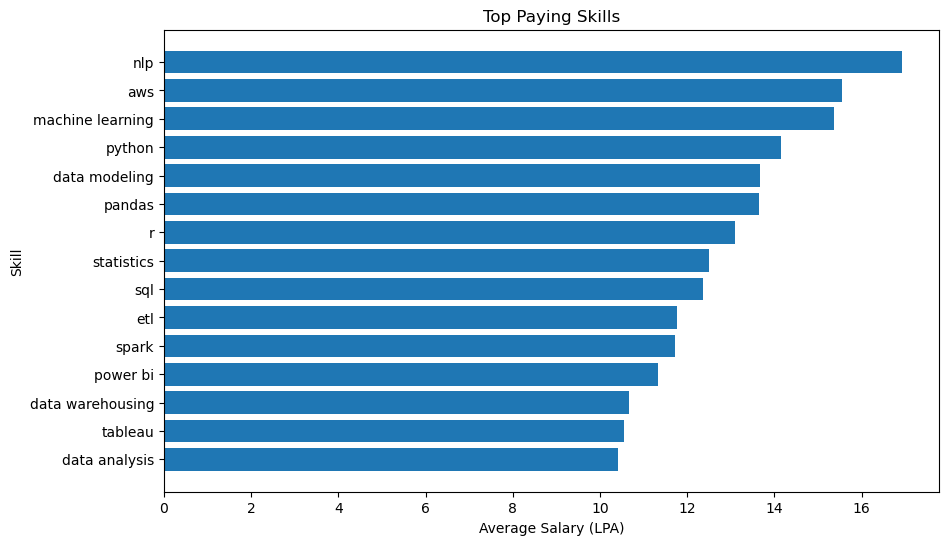

In [18]:
top_salary_skills = (
    skill_salary
    .sort_values(by='avg_salary', ascending=False)
    .head(15)
)

plt.figure(figsize=(10,6))

plt.barh(
    top_salary_skills['skills'],
    top_salary_skills['avg_salary']
)

plt.xlabel('Average Salary (LPA)')
plt.ylabel('Skill')
plt.title('Top Paying Skills')

plt.gca().invert_yaxis()

plt.show()

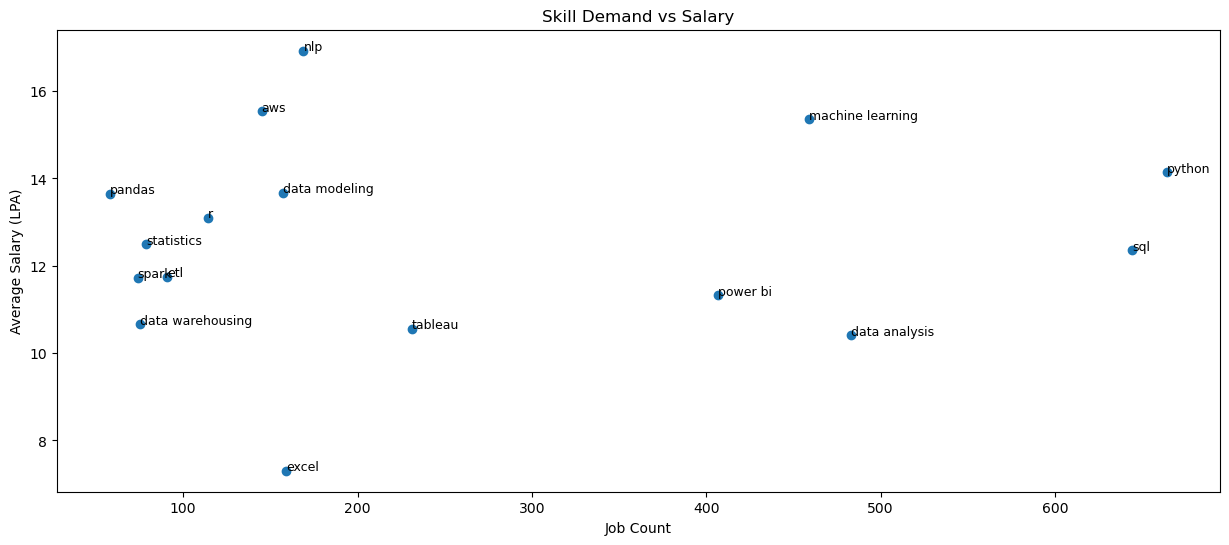

In [19]:
plt.figure(figsize=(15,6))

plt.scatter(
    skill_salary['job_count'],
    skill_salary['avg_salary']
)

for i, row in skill_salary.iterrows():
    plt.text(
        row['job_count'],
        row['avg_salary'],
        row['skills'],
        fontsize=9
    )

plt.xlabel('Job Count')
plt.ylabel('Average Salary (LPA)')
plt.title('Skill Demand vs Salary')

plt.show()

In [20]:
python_impact = (
    df.groupby('has_python')
    .agg(
        avg_salary=('salary_mid', 'mean'),
        median_salary=('salary_mid', 'median'),
        total_jobs=('has_python', 'count')
    )
    .reset_index()
)

In [21]:
python_impact

,has_python,avg_salary,median_salary,total_jobs
0,0,10.989975,8.0,1010
1,1,13.291092,12.5,798


In [22]:
python_impact['has_python'] = (
    python_impact['has_python']
    .map({
        0: 'No Python',
        1: 'Python Required'
    })
)

In [23]:
python_impact

,has_python,avg_salary,median_salary,total_jobs
0,No Python,10.989975,8.0,1010
1,Python Required,13.291092,12.5,798


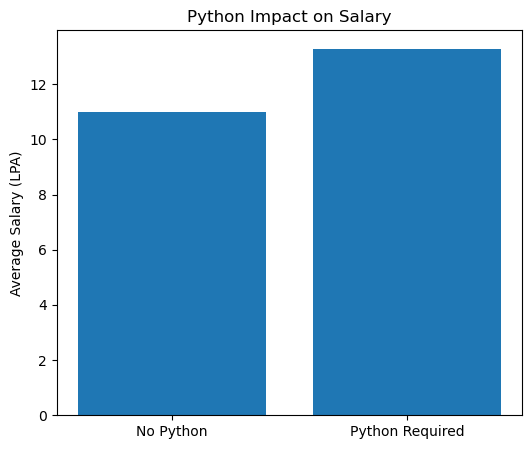

In [24]:
plt.figure(figsize=(6,5))

plt.bar(
    python_impact['has_python'],
    python_impact['avg_salary']
)

plt.ylabel('Average Salary (LPA)')
plt.title('Python Impact on Salary')

plt.show()

In [25]:
import ast

df['required_skill'] = df['required_skill'].apply(ast.literal_eval)

In [26]:
core_skills = [

    'python',
    'sql',
    'excel',
    'power bi',
    'tableau',

    'pandas',
    'numpy',

    'machine learning',
    'deep learning',
    'nlp',

    'aws',
    'spark',

    'statistics',
    'data visualization',
    'data analysis',
    'data analytics',

]

In [27]:
from itertools import combinations
from collections import Counter

skill_pairs = []

for skills in df['required_skill']:

    # remove duplicates
    skills = list(set(skills))

    # only keep core skills
    skills = [s for s in skills if s in core_skills]

    pairs = combinations(sorted(skills), 2)

    skill_pairs.extend(pairs)

pair_counts = Counter(skill_pairs)

In [28]:
pair_df = pd.DataFrame(
    pair_counts.items(),
    columns=['skill_pair', 'count']
)

pair_df['skill_1'] = pair_df['skill_pair'].apply(lambda x: x[0])
pair_df['skill_2'] = pair_df['skill_pair'].apply(lambda x: x[1])

pair_df = pair_df.sort_values(
    by='count',
    ascending=False
)

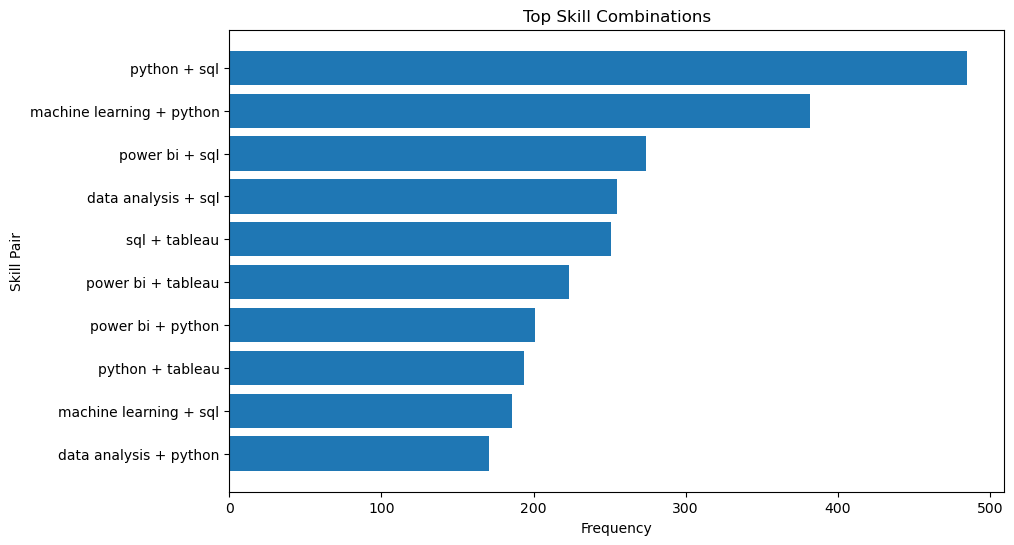

In [29]:
top_pairs = pair_df.head(10)

pair_names = (
    top_pairs['skill_1']
    + ' + '
    + top_pairs['skill_2']
)

plt.figure(figsize=(10,6))

plt.barh(
    pair_names,
    top_pairs['count']
)

plt.xlabel('Frequency')
plt.ylabel('Skill Pair')
plt.title('Top Skill Combinations')

plt.gca().invert_yaxis()

plt.show()

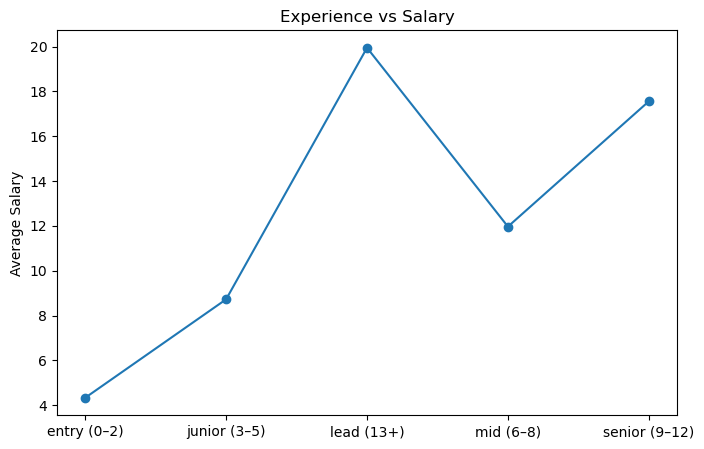

In [30]:
exp_salary = (
    df.groupby('exp_bucket')
    .agg(avg_salary=('salary_mid', 'mean'))
    .reset_index()
)

plt.figure(figsize=(8,5))

plt.plot(
    exp_salary['exp_bucket'],
    exp_salary['avg_salary'],
    marker='o'
)

plt.ylabel('Average Salary')
plt.title('Experience vs Salary')

plt.show()

In [32]:
import os

os.makedirs('powerbi_exports', exist_ok=True)

df.to_csv('powerbi_exports/jobs_master.csv', index=False)
df_exploded.to_csv('powerbi_exports/skills_exploded.csv', index=False)
pair_df.to_csv('powerbi_exports/skill_pairs.csv', index=False)

In [31]:
# df_skill_focus.to_csv('df_skill_focus.csv', index = False)